# E-Commerce Customer Churn Prediction
---
> **Tujuan:** Membangun model klasifikasi untuk memprediksi pelanggan yang berpotensi churn pada platform e-commerce, sehingga tim bisnis dapat mengambil tindakan preventif yang tepat sasaran.


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport

#modul untuk ML
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, StackingClassifier, GradientBoostingClassifier, AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#model
from sklearn.neural_network import MLPClassifier
from sklearn import svm
from sklearn.linear_model import SGDClassifier,Perceptron,PassiveAggressiveClassifier,RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis,LinearDiscriminantAnalysis


#imputer
from sklearn.impute import SimpleImputer

#scaler
from sklearn.preprocessing import  RobustScaler

#encoder
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder


#column transformer
from sklearn.compose import ColumnTransformer

#pipeline
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

#feature selection
from sklearn.feature_selection import SelectKBest, f_classif

#resampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NeighbourhoodCleaningRule

#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split

#metric
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, fbeta_score, make_scorer, RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth',None)

## 2. Load Dataset

In [2]:
df = pd.read_csv('data_ecommerce_customer_churn.csv')
df

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


## 3. Introduction

### 3a. Context
E-commerce adalah salah satu industri yang paling kompetitif saat ini. Pelanggan memiliki banyak pilihan platform, sehingga loyalitas pelanggan menjadi aset yang sangat berharga. **Churn** (berhentinya pelanggan menggunakan layanan) adalah tantangan utama yang dihadapi bisnis e-commerce karena biaya akuisisi pelanggan baru jauh lebih tinggi dibandingkan biaya retensi pelanggan yang sudah ada.

Dataset ini berisi informasi perilaku dan demografi pelanggan pada sebuah platform e-commerce, dengan label target `Churn` (1 = churn, 0 = tidak churn).

---

### 3b. Business Problem
Platform e-commerce mengalami kehilangan pendapatan yang signifikan akibat customer churn. Tim bisnis saat ini tidak memiliki mekanisme yang andal untuk mengidentifikasi pelanggan yang berisiko churn **sebelum mereka benar-benar meninggalkan platform**, sehingga tidak dapat melakukan intervensi yang tepat waktu.

> ? *"Bagaimana kita dapat mengidentifikasi pelanggan yang berpotensi churn sedini mungkin agar dapat dilakukan tindakan retensi yang efektif dan efisien?"*

---

### 3c. Goals
1. Membangun model machine learning yang mampu **memprediksi pelanggan yang berpotensi churn** dengan performa tinggi.
2. Meminimalkan pelanggan churn yang **tidak terdeteksi** (False Negative), karena setiap pelanggan yang tidak tertangani berpotensi menyebabkan kerugian pendapatan.
3. Memberikan insight kepada tim bisnis mengenai **faktor-faktor utama** yang mendorong terjadinya churn.

---

### 3d. Analytical Approach
1. **Exploratory Data Analysis (EDA):** Memahami distribusi data, pola churn, dan hubungan antar fitur.
2. **Feature Engineering:** Melakukan preprocessing, encoding, scaling, dan transformasi fitur menggunakan Pipeline dan ColumnTransformer.
3. **Model Benchmarking:** Membandingkan berbagai algoritma klasifikasi untuk memilih kandidat terbaik.
4. **Penalized Model (Class Weight):** Menangani imbalanced class dengan `class_weight='balanced'` dan dibandingkan dengan resampling.
5. **Hyperparameter Tuning:** Mengoptimalkan model terpilih menggunakan RandomizedSearchCV.
6. **Model Evaluation:** Mengevaluasi model pada data test dan melakukan analisis biaya-manfaat.
7. **Model Interpretability:** Menggunakan SHAP untuk memahami kontribusi fitur.

---

### 3e. Stakeholders

| Stakeholder | Peran | Kepentingan |
|-------------|-------|-------------|
| **Tim Bisnis / Marketing** | User Utama | Menggunakan output model untuk menargetkan program retensi (diskon, voucher, dll.) |

---

### 3f. Metric Selection

Karena dataset ini **imbalanced** (pelanggan non-churn >> churn) dan konsekuensi dari **False Negative (pelanggan churn yang tidak terdeteksi) jauh lebih merugikan** daripada False Positive (pelanggan non-churn yang salah diprediksi churn):

| Metrik | Alasan Pemilihan |
|--------|------------------|
| **FBeta Score (β=3)** | Metrik utama. Menggabungkan Recall dan Precision dengan bobot Recall 9× lebih penting dari Precision — meminimalkan FN secara agresif |
| **Recall** | Metrik sekunder. Meminimalkan FN: pelanggan yang churn namun tidak terdeteksi = kerugian pendapatan langsung |
| **PR-AUC** | Lebih informatif dari ROC-AUC pada kasus imbalanced class |

>   **Prioritas Utama: FBeta Score (β=3)** — Recall diberi bobot 9× lebih besar dari Precision. Lebih baik salah memprediksi seseorang akan churn (FP) daripada melewatkan pelanggan yang benar-benar akan churn (FN). FBeta memastikan optimisasi model tetap memperhitungkan keseimbangan, bukan hanya memaksimalkan Recall secara membabi-buta.

---

### 3g. 5-Point Business ML Goals Summary

| # | Komponen | Deskripsi |
|---|----------|-----------|
| 1 | **Problem** | Tingginya customer churn pada platform e-commerce yang tidak terdeteksi secara proaktif |
| 2 | **Data** | Data historis pelanggan: demografi, perilaku transaksi, kepuasan, dan label churn |
| 3 | **ML Objective** | Binary classification — memprediksi apakah seorang pelanggan akan churn (1) atau tidak (0) |
| 4 | **Action** | Output prediksi digunakan tim marketing untuk menyasar program retensi (voucher, diskon, personal outreach) kepada pelanggan berisiko tinggi |
| 5 | **Value** | Mengurangi customer churn rate, meningkatkan Customer Lifetime Value (CLV), dan menghemat biaya akuisisi pelanggan baru |


## 4. Data Understanding

Dataset yang digunakan adalah **E-Commerce Customer Churn Dataset**, yang berisi informasi demografi dan perilaku pelanggan pada sebuah platform e-commerce.

- **Sumber Data:** Data internal perusahaan e-commerce (simulasi/studi kasus)
- **Periode Data:** Data historis transaksi dan perilaku pelanggan
- **Jumlah Fitur Awal:** 20 kolom (termasuk target)
- **Target Variable:** `Churn` (1 = churn, 0 = tidak churn)

**Deskripsi Fitur:**

| Fitur | Tipe | Deskripsi |
|-------|------|-----------|
| Churn | int | Label target (1=Churn, 0=Tidak) |
| Tenure | float | Lama berlangganan (bulan) |
| WarehouseToHome | float | Jarak gudang ke rumah (km) |
| NumberOfDeviceRegistered | int | Jumlah perangkat terdaftar |
| PreferedOrderCat | object | Kategori pembelian favorit |
| SatisfactionScore | int | Skor kepuasan pelanggan (1-5) |
| MaritalStatus | object | Status pernikahan |
| NumberOfAddress | int | Jumlah alamat pengiriman terdaftar |
| Complain | int | Pernah komplain dalam 1 bulan terakhir (1=Ya, 0=Tidak) |
| DaySinceLastOrder | float | Hari sejak order terakhir |
| CashbackAmount | float | Rata-rata cashback yang diterima |

In [3]:
# Shape dan info dasar dataset
print(f"Jumlah baris   : {df.shape[0]}")
print(f"Jumlah kolom   : {df.shape[1]}")
print()
df.info()

Jumlah baris   : 3941
Jumlah kolom   : 11

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


In [4]:
# cek missing value
df.isna().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

<Axes: >

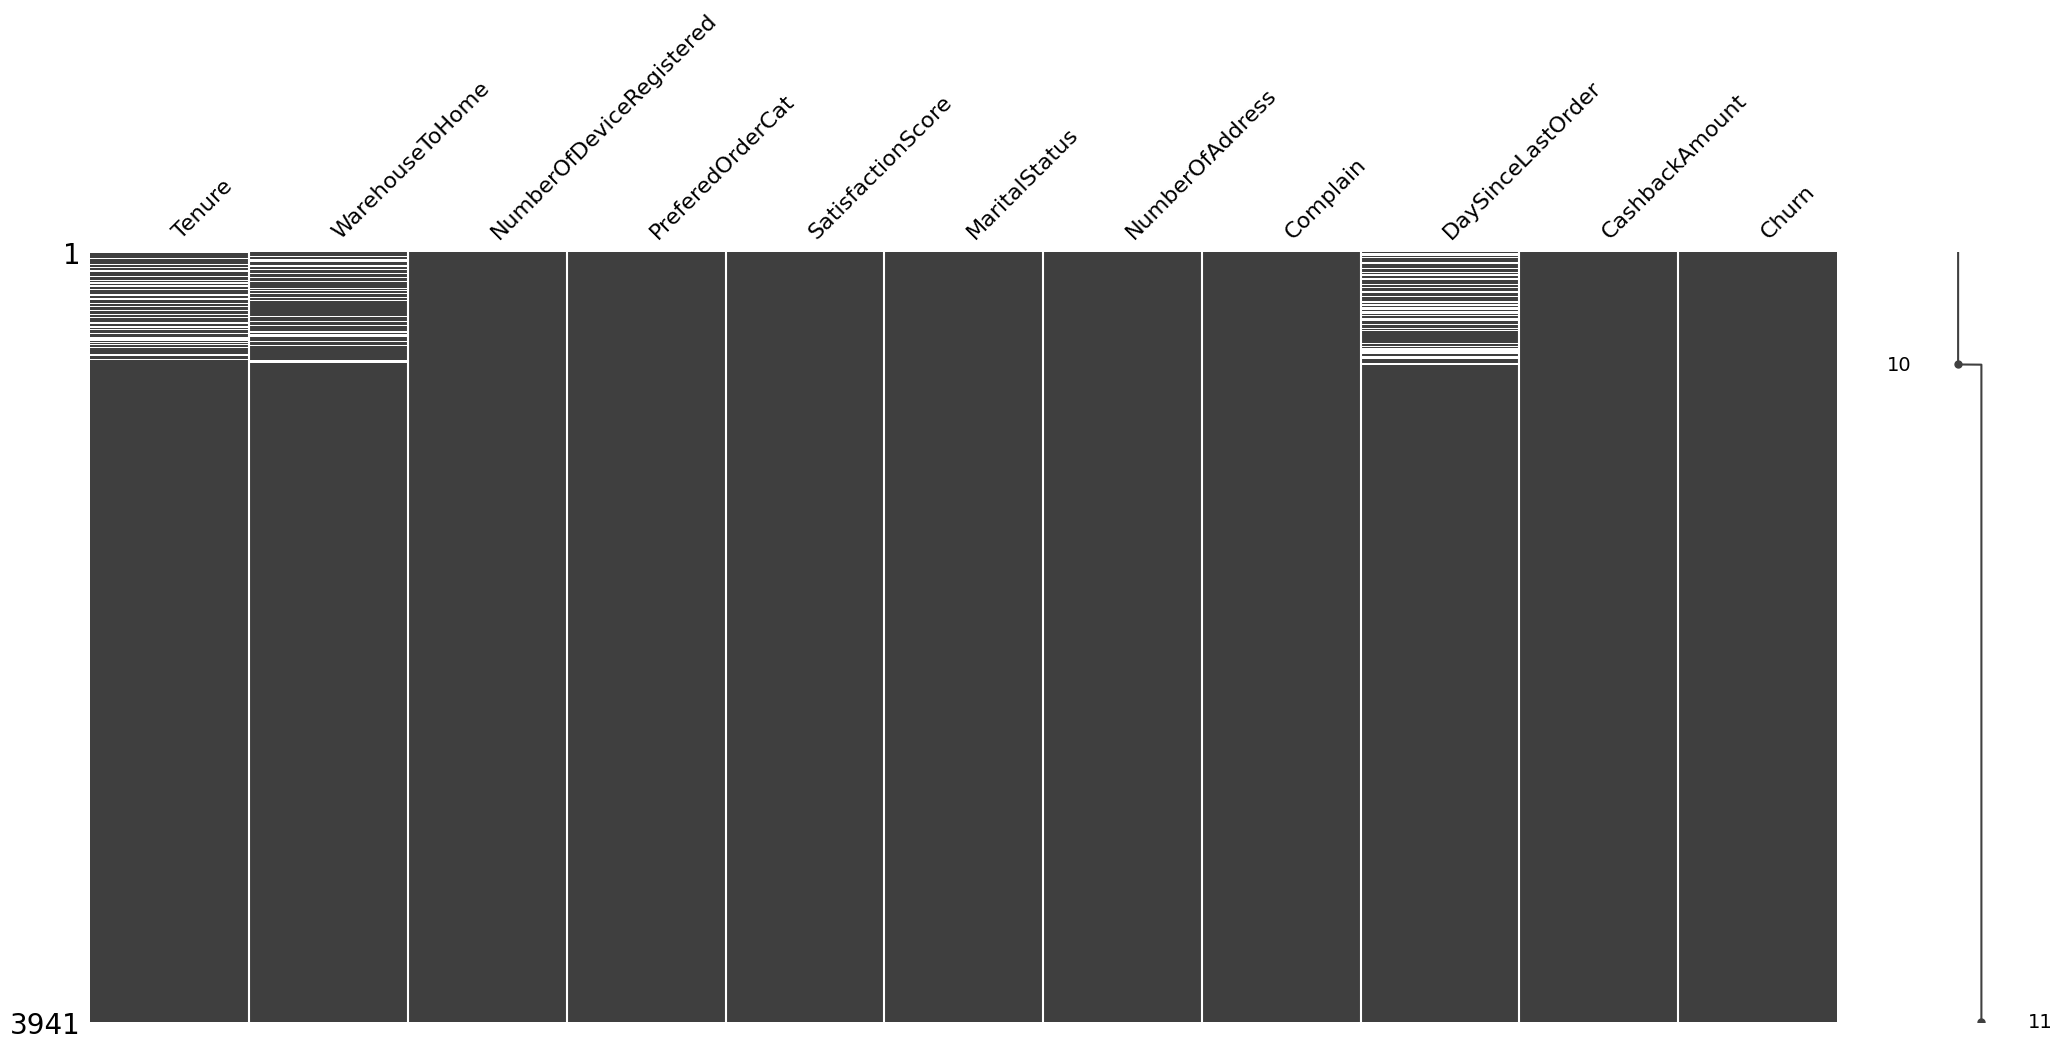

In [5]:
# visual missing value
msno.matrix(df, sort='ascending')

In [6]:
# cek duplikat
df.duplicated().sum()

np.int64(671)

sebanyak 671 data merupakan duplikat

In [7]:
# drop duplikat
df_clean = df.drop_duplicates()
df_clean

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3933,25.0,15.0,5,Fashion,4,Married,7,0,8.0,249.90,0
3935,26.0,7.0,4,Grocery,1,Married,4,0,9.0,295.99,0
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0


Tenure                      160
WarehouseToHome             135
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           181
CashbackAmount                0
Churn                         0
dtype: int64


<Axes: >

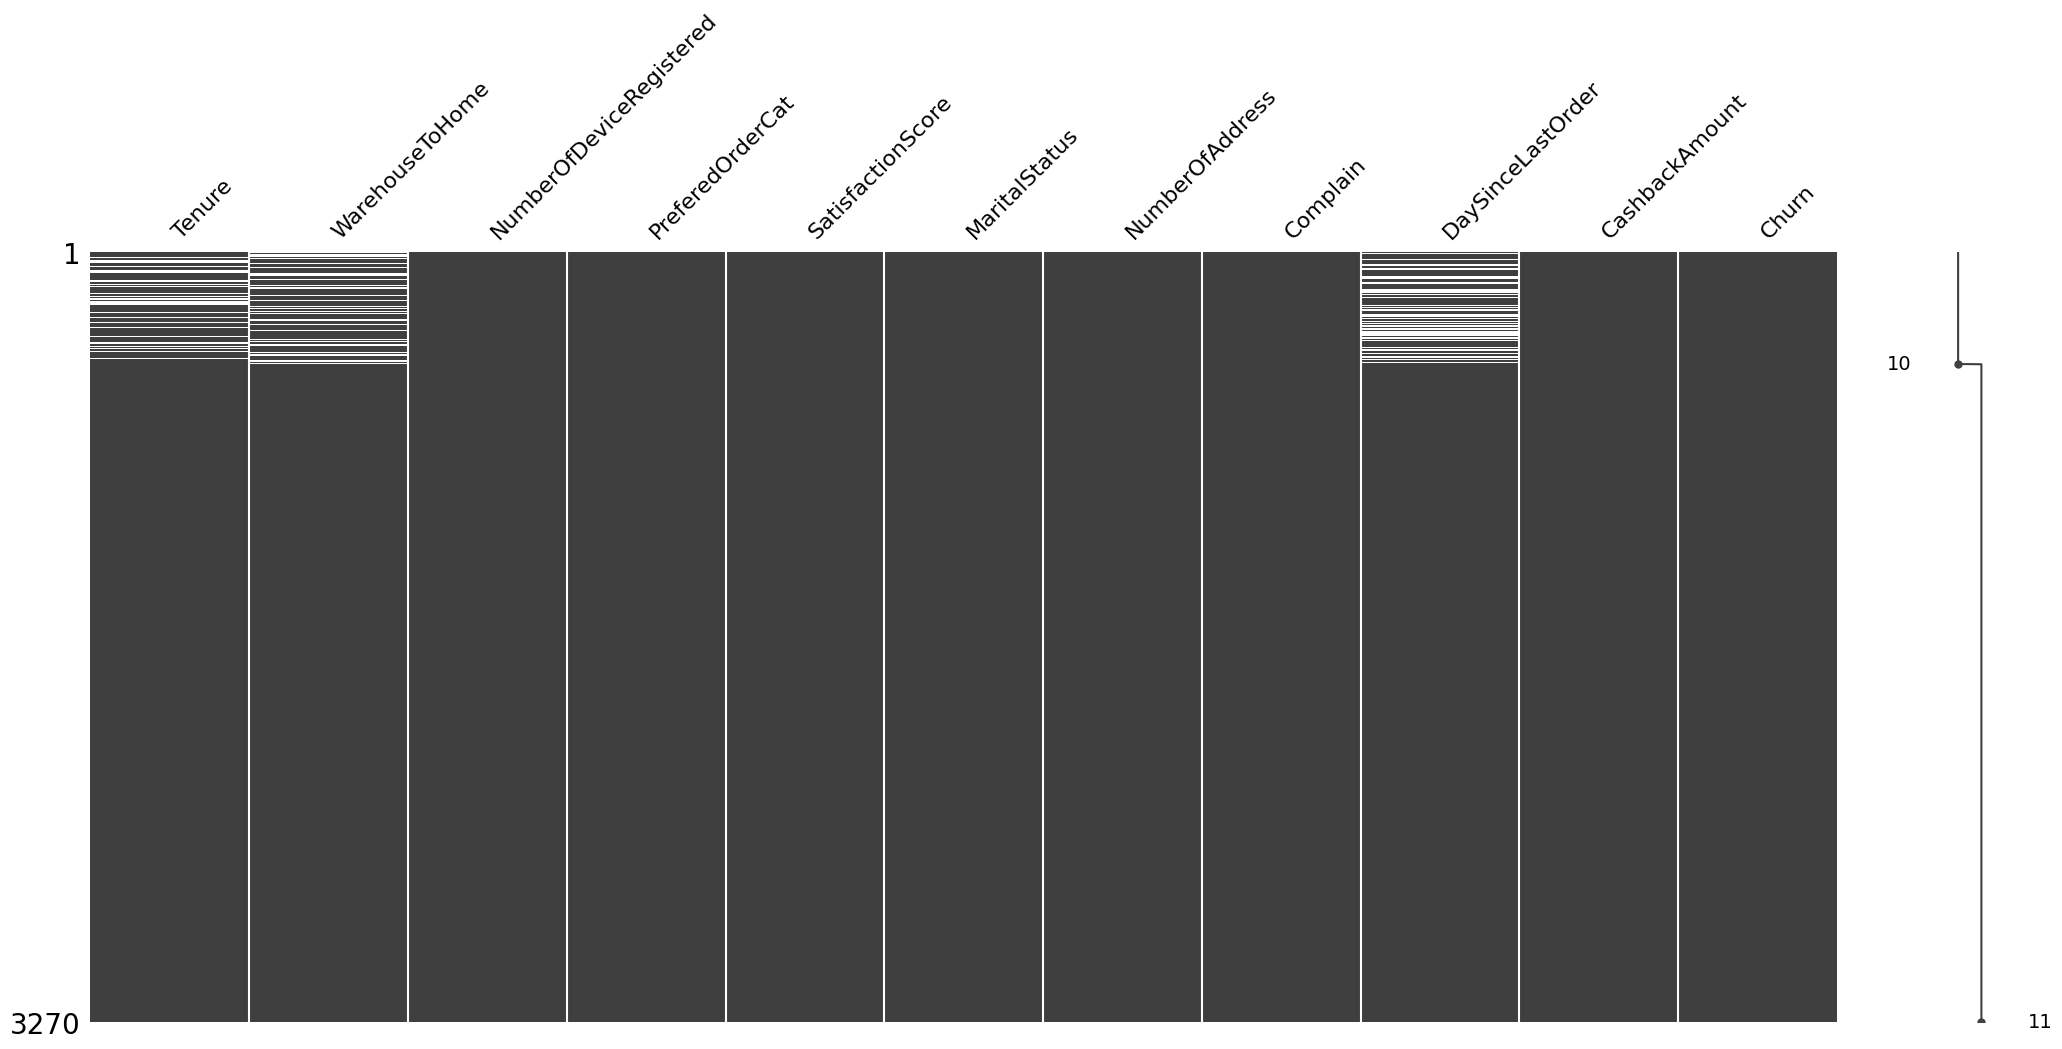

In [8]:
# cek missing value setel menghilangkan duplikat
print(df_clean.isna().sum())
msno.matrix(df_clean, sort='ascending')

terjadi penurunan missing value

In [9]:
# statistik dasar kolom numerik
df_clean.describe()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3110.000000,3135.000000,3270.000000,3270.000000,3270.000000,3270.000000,3089.000000,3270.000000,3270.000000
mean,10.190354,15.510367,3.676453,3.020795,4.222936,0.281651,4.545484,177.417670,0.163303
std,8.650821,8.568382,1.017390,1.395113,2.623195,0.449873,3.696022,49.310647,0.369698
min,0.000000,5.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,9.000000,3.000000,2.000000,2.000000,0.000000,2.000000,145.892500,0.000000
50%,9.000000,13.000000,4.000000,3.000000,3.000000,0.000000,3.000000,163.885000,0.000000
75%,16.000000,20.000000,4.000000,4.000000,6.000000,1.000000,7.000000,197.137500,0.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,1.000000,46.000000,324.990000,1.000000


In [10]:
# statistik dasar kolom kategorik
df_clean.describe(include='object')

,PreferedOrderCat,MaritalStatus
count,3270,3270
unique,6,3
top,Laptop & Accessory,Married
freq,1213,1686


In [11]:
#cek unique value
for i in df_clean.columns:
    print(i.capitalize())
    print(df_clean[i].unique())
    print(' ')

Tenure
[15.  7. 27. 20. 30.  1. 11. 17.  6. 16. 10. nan  8. 19.  0.  3.  5.  9.
 18. 12. 24.  4. 61. 25. 13. 14.  2. 21. 29. 26. 23. 31. 22. 28. 51. 60.
 50.]
 
Warehousetohome
[ 29.  25.  13.  15.  16.  11.  12.   7.  26.  20.  14.   8.  21.  22.
  27.  18.  33.   9.  17.  nan   6.  31.  28.  10.  19.  32.  23.  30.
  35.  34.  24.   5.  36. 127.]
 
Numberofdeviceregistered
[4 3 6 2 5 1]
 
Preferedordercat
['Laptop & Accessory' 'Mobile' 'Fashion' 'Others' 'Mobile Phone' 'Grocery']
 
Satisfactionscore
[3 1 4 2 5]
 
Maritalstatus
['Single' 'Married' 'Divorced']
 
Numberofaddress
[ 2  5  7  8  3  1  9  4 10 11  6 19 22 21]
 
Complain
[0 1]
 
Daysincelastorder
[ 7. nan  8. 11.  2.  1.  4.  3.  6.  0. 14.  9. 10. 12.  5. 17. 30. 18.
 16. 13. 15. 46. 31.]
 
Cashbackamount
[143.32 129.29 168.54 ... 147.66 231.86 153.73]
 
Churn
[0 1]
 


In [12]:
# Konversi kolom numerikal ke tipe float64 untuk konsistensi
cols_to_convert = ['NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress','Complain', 'Churn']
for col in cols_to_convert:
    df_clean[col] = df_clean[col].astype(np.float64)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3270 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3110 non-null   float64
 1   WarehouseToHome           3135 non-null   float64
 2   NumberOfDeviceRegistered  3270 non-null   float64
 3   PreferedOrderCat          3270 non-null   object 
 4   SatisfactionScore         3270 non-null   float64
 5   MaritalStatus             3270 non-null   object 
 6   NumberOfAddress           3270 non-null   float64
 7   Complain                  3270 non-null   float64
 8   DaySinceLastOrder         3089 non-null   float64
 9   CashbackAmount            3270 non-null   float64
 10  Churn                     3270 non-null   float64
dtypes: float64(9), object(2)
memory usage: 306.6+ KB


In [13]:
# Mengubah semua 'Mobile' menjadi 'Mobile Phone' agar seragam
df_clean['PreferedOrderCat'] = df_clean['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

# Cek hasilnya
print(df_clean['PreferedOrderCat'].value_counts())

PreferedOrderCat
Laptop & Accessory    1213
Mobile Phone          1183
Fashion                484
Grocery                241
Others                 149
Name: count, dtype: int64


### Exploratory Data Analysis (EDA)

In [14]:
# auto eda 
eda = ProfileReport(df_clean)
eda.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 327.92it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

#### Distribusi Fitur Numerik

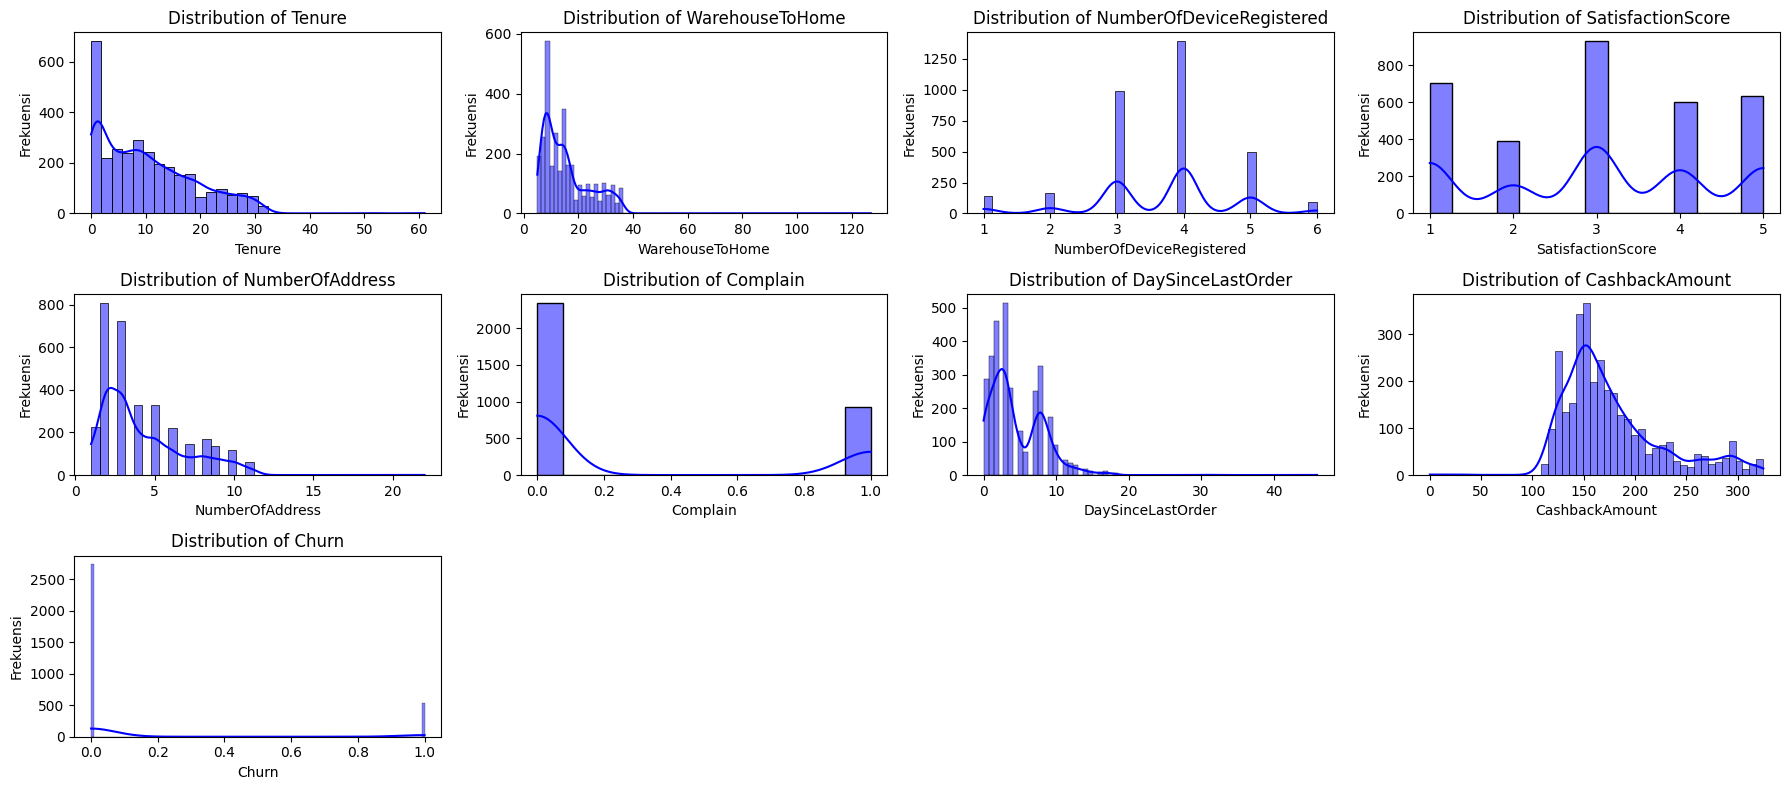

In [15]:
# menentukan ukuran figure untuk subplot
plt.figure(figsize=(18,8))

# looping melalui setiap kolom untuk menampilkan distribusi dan boxplot
numeric_columns = df_clean.select_dtypes(include='number').columns
for i, column in enumerate(numeric_columns, 1):
    # Subplot untuk distribusi
    plt.subplot(3, 4, i)
    sns.histplot(df_clean[column], kde=True, color='blue')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frekuensi')
    
# Menampilkan visualisasi
plt.tight_layout()
plt.show()

tidak ada yang terdistribusi normal

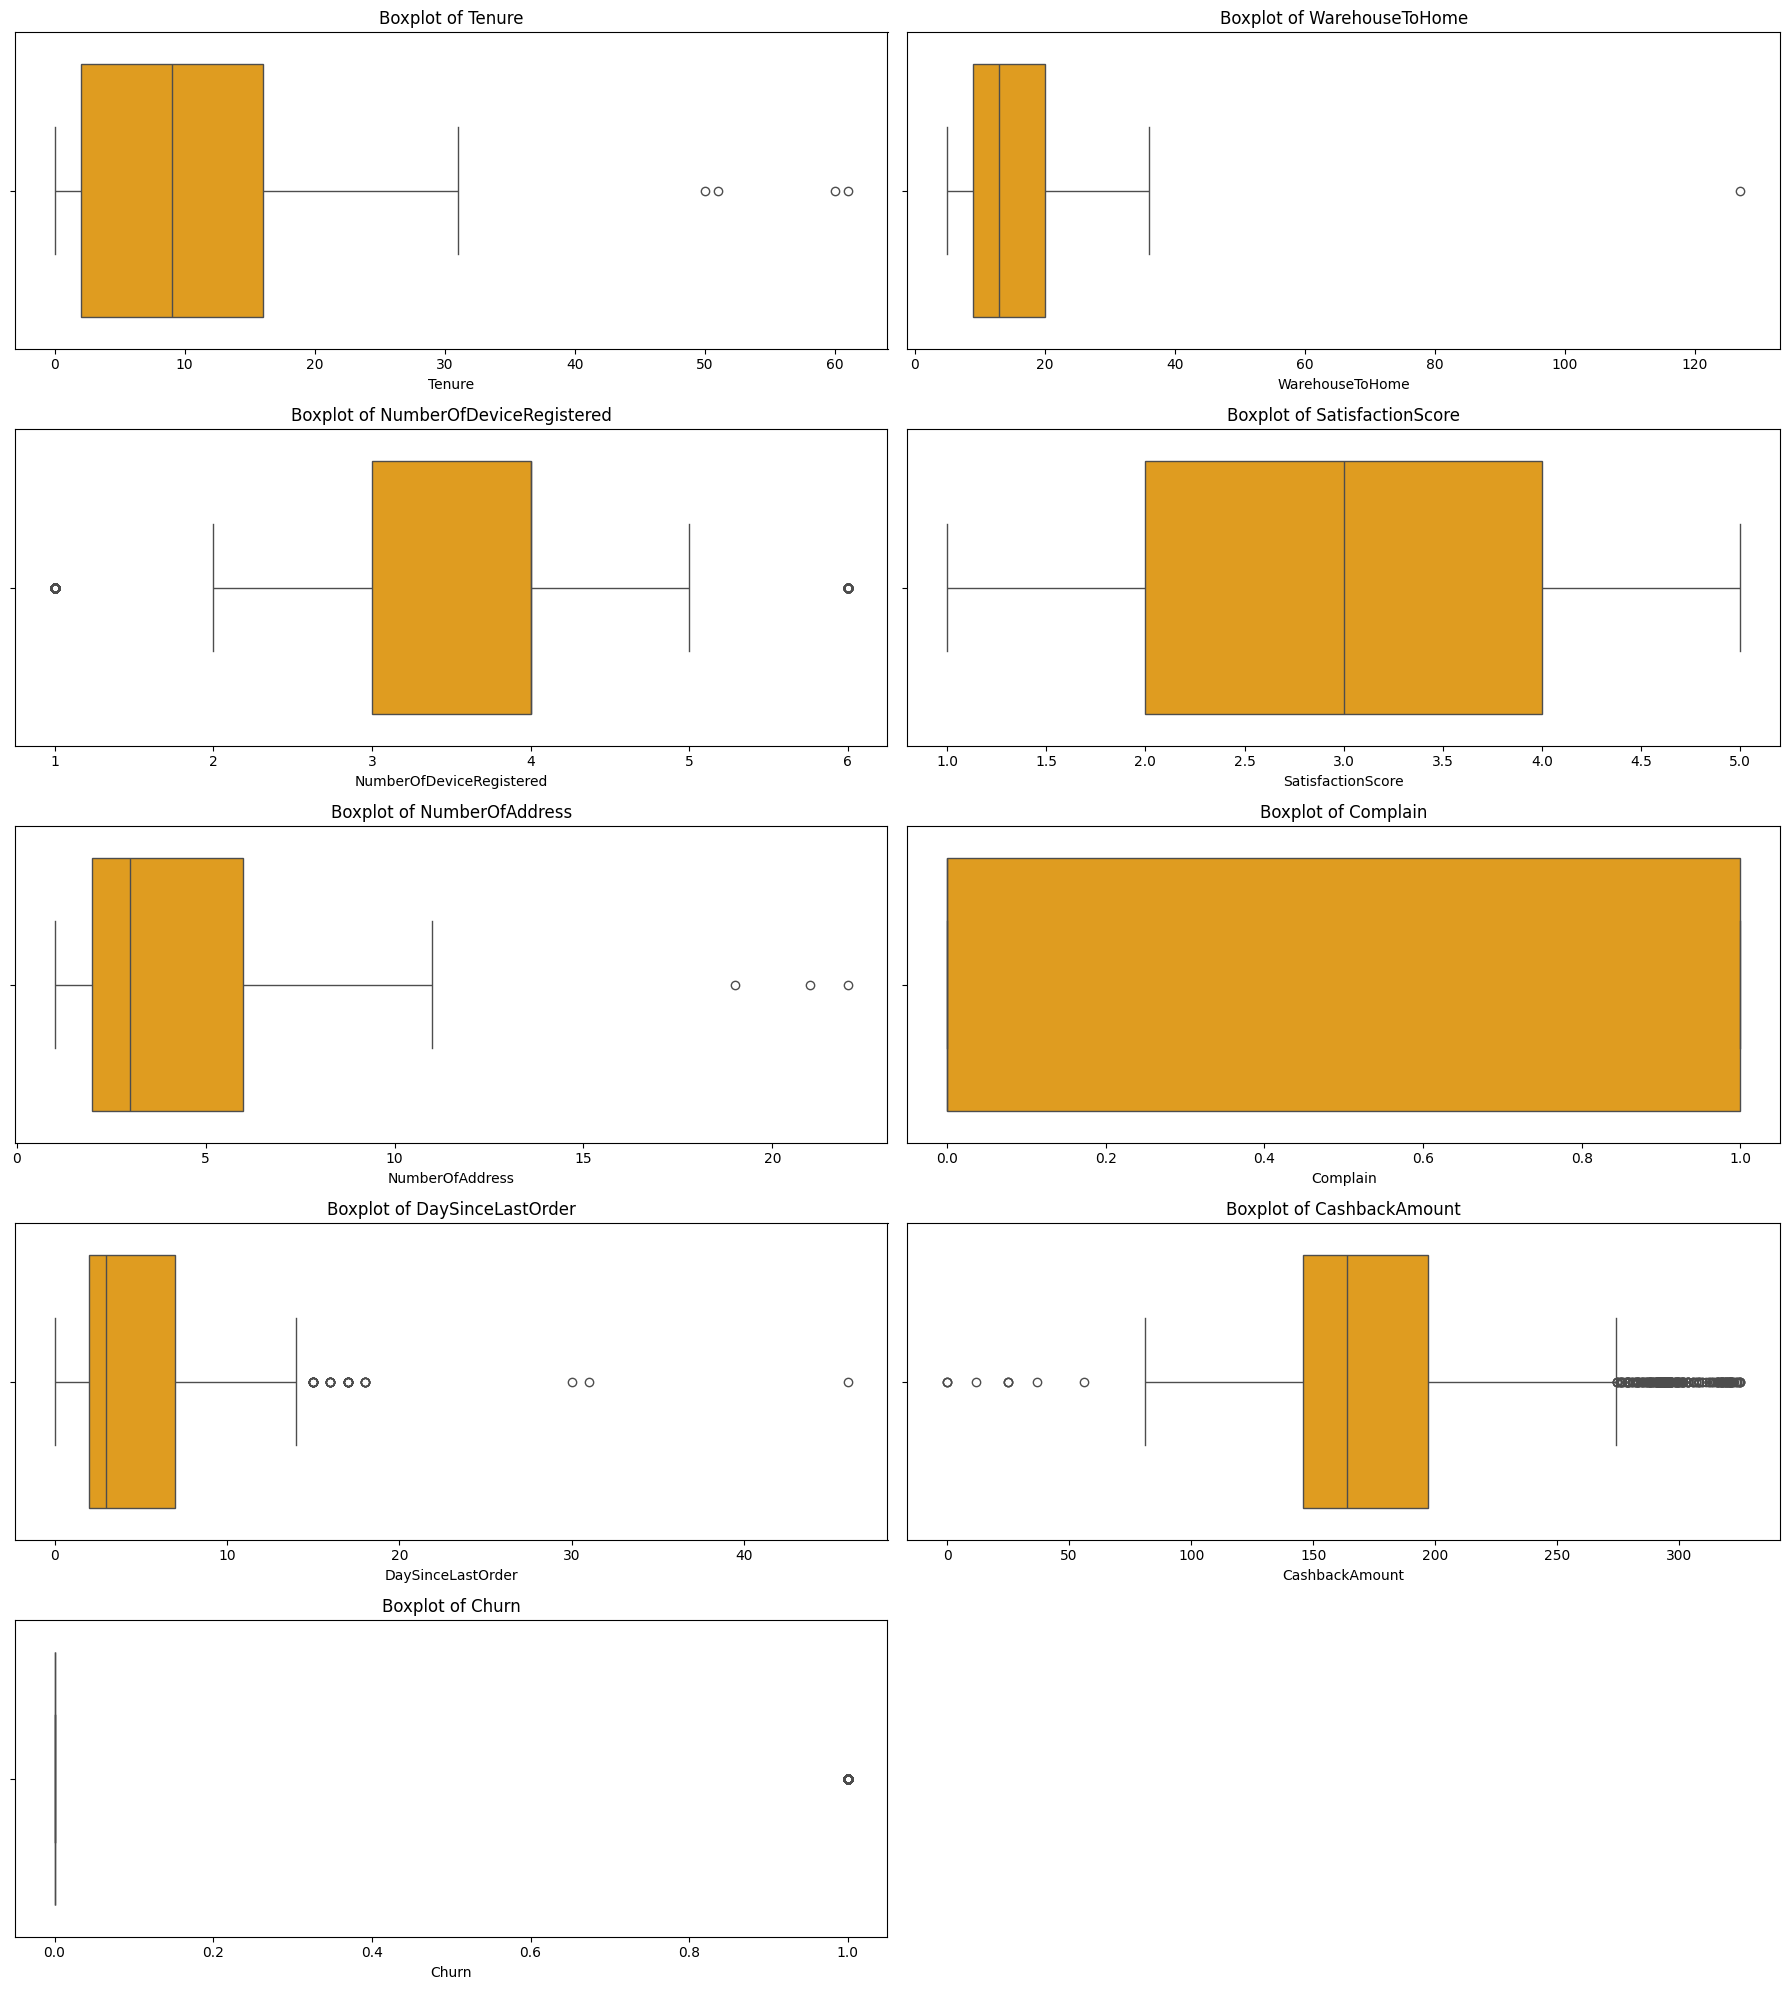

In [16]:
# menentukan ukuran figure untuk subplot
plt.figure(figsize=(18,20))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(x=df_clean[column], color='orange')
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

#### Distribusi Target Variable (Churn)

Number of customers who churned: 534
Number of customers who did not churn: 2736
Churn ratio: 0.20


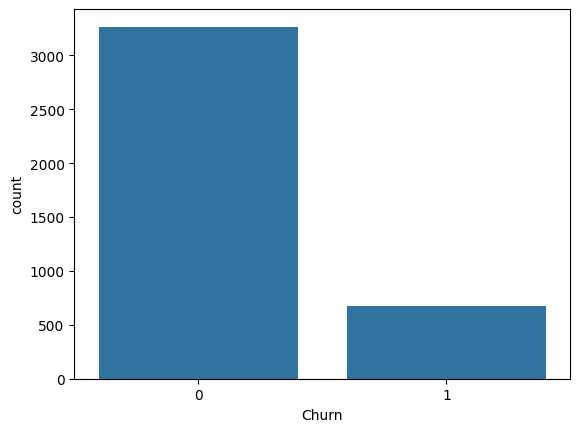

In [17]:
churn_counts = df_clean['Churn'].value_counts()

print(f"Number of customers who churned: {churn_counts[1]}")
print(f"Number of customers who did not churn: {churn_counts[0]}")

churn_ratio = churn_counts[1] / churn_counts[0]
print(f"Churn ratio: {churn_ratio:.2f}")


sns.countplot(x = 'Churn', data = df)
plt.show()

terdapat imbalance ratio antara churn dan tidak churn

## 5. Define X and y

Memisahkan fitur (X) dan target variabel (y).
- **X** : Semua kolom kecuali kolom target `Churn`
- **y** : Kolom `Churn` (0 = tidak churn, 1 = churn)


In [18]:
X = df_clean.drop(columns='Churn')  # drop ID karena bukan fitur prediktif
y = df_clean['Churn']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print()
print("Distribusi target:")
print(y.value_counts())
print()
print(f"Proporsi churn: {y.mean()*100:.2f}%")

Shape X: (3270, 10)
Shape y: (3270,)

Distribusi target:
Churn
0.0    2736
1.0     534
Name: count, dtype: int64

Proporsi churn: 16.33%


## 6. Data Splitting

Membagi dataset menjadi **training set (80%)** dan **test set (20%)** menggunakan `train_test_split` dengan stratifikasi untuk menjaga proporsi kelas yang seimbang.

> Penting:** Splitting dilakukan **sebelum** feature engineering untuk mencegah data leakage.


In [19]:
# Memisahkan fitur (X) dan target (y)
# Kolom 'YearBuilt' dihapus karena sudah direpresentasikan oleh 'Age'
X = df_clean.drop(columns='Churn')
y = df_clean['Churn']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=10
)

print(f"Ukuran data training : {X_train.shape}")
print(f"Ukuran data testing  : {X_test.shape}")

Ukuran data training : (2616, 10)
Ukuran data testing  : (654, 10)


## 7. Feature Engineering

Mendefinisikan **ColumnTransformer** dan **Pipeline** untuk preprocessing data:

| Transformasi | Kolom | Alasan |
|---|---|---|
| `OneHotEncoder` | MaritalStatus | Nominal kategorikal tanpa urutan |
| `BinaryEncoder` | PreferedOrderCat | Kategorikal dengan banyak unique value |
| `SimpleImputer (median)` | Tenure, WarehouseToHome, DaySinceLastOrder | Menangani missing value di fitur numerik skewed |
| `RobustScaler` | Semua fitur numerik | Tahan terhadap outlier |

>  Semua transformasi dimasukkan ke dalam **Pipeline** agar proses dapat direproduksi dan bebas dari data leakage.


In [20]:
num_features = [
   'Tenure', 'WarehouseToHome', 'DaySinceLastOrder',
]

transformer = ColumnTransformer([
    ('cat_hot', OneHotEncoder(drop='first'), ['MaritalStatus']),
    ('cat_bin', ce.BinaryEncoder(), ['PreferedOrderCat']),
    ('cat_ord', SimpleImputer(strategy='median'), num_features)
], remainder='passthrough')

## 8. Model Benchmarking

Melakukan benchmarking terhadap berbagai algoritma klasifikasi menggunakan **cross-validation (StratifiedKFold, 5 fold)** untuk menemukan kandidat model terbaik.

**Metrik Evaluasi:** FBeta Score β=5 (prioritas utama), Recall, F1-Score, Precision, Accuracy


In [21]:
#resampler
ncr=NeighbourhoodCleaningRule()
smote=SMOTE(random_state=10)

#SKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

#model
logreg=LogisticRegression(random_state=10)
tree=DecisionTreeClassifier(random_state=10)
knn=KNeighborsClassifier()
voting_soft=VotingClassifier([('clf1',logreg),('clf2',tree),('clf3', knn)],voting='soft')
voting_hard=VotingClassifier([('clf1',logreg),('clf2',tree),('clf3', knn)],voting='hard')
stack=StackingClassifier([('clf1',logreg),('clf2',tree),('clf3', knn)],
                 final_estimator=tree #meta classifier
                        )
bagging=BaggingClassifier(tree,random_state=10)
rf=RandomForestClassifier(random_state=10)
ada=AdaBoostClassifier(random_state=10)
xgb=XGBClassifier(random_state=10)
lgbm=LGBMClassifier(random_state=10)
cat=CatBoostClassifier(random_state=10)
mlp=MLPClassifier(random_state=10)
nb=GaussianNB()
sgd=SGDClassifier(random_state=10)
sv=svm.SVC(random_state=10)
qda = QuadraticDiscriminantAnalysis()
lda = LinearDiscriminantAnalysis()
perceptron = Perceptron(random_state=10)
pac = PassiveAggressiveClassifier(random_state=10)
etc = ExtraTreesClassifier(random_state=10)
ridge = RidgeClassifier(random_state=10)
hgb = HistGradientBoostingClassifier(random_state=10)



In [22]:
import time
select_kbest=SelectKBest(score_func=f_classif,k=20)


# 1. Setup CV Strategy
# Menggunakan StratifiedKFold agar proporsi kelas tetap seimbang di setiap fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

# 2. Inisialisasi Pipeline Dasar
# Nama step harus konsisten dengan yang ada di param_grid
pipeline = ImbPipeline(steps=[
    ('preprocessor', transformer),
    ('scaler', RobustScaler()),
    ('feature_selection', select_kbest),   
    ('resampler', smote),   
    ('classifier', logreg)   
])

# 3. Parameter Grid (Sudah mencakup semua model dan resampler)
all_models = [
    logreg, tree, knn, voting_hard, voting_soft, stack, bagging, rf, 
    ada, xgb, lgbm, cat, mlp, nb, sv, sgd, qda, lda, perceptron, 
    pac, etc, ridge, hgb
]
param_grid = [
    {
        'classifier': [model], 
        'feature_selection__k': [10, 20], 
        'resampler': [ncr, smote]
    } 
    for model in all_models
]


# 4. Setup GridSearchCV
# Menggunakan FBeta Score (beta=5) sebagai metrik utama: bobot Recall 5x lebih penting dari Precision
fbeta_scorer = make_scorer(fbeta_score, beta=3)
gscv = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=skf, 
    n_jobs=-1, 
    scoring=fbeta_scorer, 
    return_train_score=True,
    verbose=1
)

# 5. Eksekusi dan Pengukuran Waktu
print("Starting Global Hyperparameter Tuning...")
start_time = time.time()
gscv.fit(X_train, y_train)
end_time = time.time()

fitting_time = end_time - start_time
print(f"Total Fitting Time: {fitting_time:.2f} seconds")

# 6. Menampilkan Hasil Pencarian Terbaik
print("-" * 30)
print(f"Best Score: {gscv.best_score_:.4f}")
print(f"Best Model/Params: {gscv.best_params_}")
print("-" * 30)

# 7. Menyusun Tabel Hasil (Mirip Baseline Results)
# Mengambil hasil CV untuk semua model yang diuji
cv_results_df = pd.DataFrame(gscv.cv_results_)

# Mempercantik tabel hasil
display_columns = ['param_classifier', 'param_resampler', 'param_feature_selection__k', 
                   'mean_test_score', 'std_test_score', 'mean_fit_time']

df_results_summary = cv_results_df[display_columns].sort_values(by='mean_test_score', ascending=False)

# Mengubah objek model di kolom param_classifier menjadi string nama model agar enak dibaca
df_results_summary['Model Name'] = df_results_summary['param_classifier'].apply(lambda x: type(x).__name__)
df_results_summary['Resampler'] = df_results_summary['param_resampler'].apply(lambda x: type(x).__name__)

display(df_results_summary[['Model Name', 'Resampler', 'param_feature_selection__k', 'mean_test_score', 'std_test_score']])

# ── Ekstrak Top-3 Best Model dari Benchmarking ───────────────────────────────
# Group by Model Name, ambil skor tertinggi per model (best config per model)
df_best_per_model = (
    df_results_summary
    .groupby('Model Name', as_index=False)
    .apply(lambda g: g.loc[g['mean_test_score'].idxmax()])
    .reset_index(drop=True)
    .sort_values('mean_test_score', ascending=False)
)

# Ambil top-3
top3_df = df_best_per_model.head(3)
print("\n=== Top-3 Best Models dari Benchmarking ===")
display(top3_df[['Model Name', 'Resampler', 'param_feature_selection__k', 'mean_test_score', 'std_test_score']])

# Simpan nama top-3 model untuk tuning
top3_model_names = top3_df['Model Name'].tolist()
print(f"\nModel yang akan di-tuning: {top3_model_names}")

# Mapping nama model ke objek model yang sudah didefinisikan
model_registry = {
    type(m).__name__: m for m in all_models
}

# Ambil objek model & config terbaik (resampler + k) untuk masing-masing top-3
top3_candidates = []
for _, row in top3_df.iterrows():
    model_name = row['Model Name']
    model_obj  = model_registry[model_name]
    best_resampler = row['param_resampler']
    best_k         = row['param_feature_selection__k']
    top3_candidates.append({
        'name':      model_name,
        'model':     model_obj,
        'resampler': best_resampler,
        'k':         best_k,
        
        'score':     row['mean_test_score'],
    })


Starting Global Hyperparameter Tuning...
Fitting 5 folds for each of 92 candidates, totalling 460 fits
Total Fitting Time: 436.36 seconds
------------------------------
Best Score: 0.7593
Best Model/Params: {'classifier': HistGradientBoostingClassifier(random_state=10), 'feature_selection__k': 20, 'resampler': NeighbourhoodCleaningRule()}
------------------------------


,Model Name,Resampler,param_feature_selection__k,mean_test_score,std_test_score
90,HistGradientBoostingClassifier,NeighbourhoodCleaningRule,20,0.759300,0.023837
71,LinearDiscriminantAnalysis,SMOTE,20,0.759200,0.031591
87,RidgeClassifier,SMOTE,20,0.757257,0.032730
46,CatBoostClassifier,NeighbourhoodCleaningRule,20,0.755613,0.044588
42,LGBMClassifier,NeighbourhoodCleaningRule,20,0.752400,0.032210
...,...,...,...,...,...
76,PassiveAggressiveClassifier,NeighbourhoodCleaningRule,10,0.556917,0.189928
10,KNeighborsClassifier,NeighbourhoodCleaningRule,20,0.548078,0.024777
77,PassiveAggressiveClassifier,SMOTE,10,0.542553,0.130724
84,RidgeClassifier,NeighbourhoodCleaningRule,10,0.497910,0.035624



=== Top-3 Best Models dari Benchmarking ===


,Model Name,Resampler,param_feature_selection__k,mean_test_score,std_test_score
6,HistGradientBoostingClassifier,NeighbourhoodCleaningRule,20,0.759300,0.023837
9,LinearDiscriminantAnalysis,SMOTE,20,0.759200,0.031591
16,RidgeClassifier,SMOTE,20,0.757257,0.032730



Model yang akan di-tuning: ['HistGradientBoostingClassifier', 'LinearDiscriminantAnalysis', 'RidgeClassifier']


## 10. Penalized Model (Class Weight = 'Balanced')

Karena dataset mengalami **class imbalance**, kita menguji pendekatan **penalized model** menggunakan `class_weight='balanced'`.

Pendekatan ini akan dibandingkan dengan:
1. **Resampling** (SMOTE / NCR)
2. **Penalized Model** (`class_weight='balanced'`)



In [23]:
# Perbandingan SMOTE vs Class Weight per kandidat top-3
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import cross_val_score

# Mapping model → cara set class_weight / imbalance handling
CLASS_WEIGHT_CAPABLE = {
    'LogisticRegression'    : ('classifier__class_weight', 'balanced'),
    'DecisionTreeClassifier': ('classifier__class_weight', 'balanced'),
    'RandomForestClassifier': ('classifier__class_weight', 'balanced'),
    'RidgeClassifier'       : ('classifier__class_weight', 'balanced'),
    'LGBMClassifier'        : ('classifier__class_weight', 'balanced'),
    'XGBClassifier'         : ('classifier__scale_pos_weight',
                                int((y_train==0).sum()/(y_train==1).sum())),
    'CatBoostClassifier'    : ('classifier__auto_class_weights', 'Balanced'),
}

scale_ratio = int((y_train==0).sum() / (y_train==1).sum())
print(f'Class ratio train: {(y_train==0).sum()}:{(y_train==1).sum()} ({scale_ratio:.1f}:1)')
print()

strategy_rows   = []
updated_cands   = []

for cand in top3_candidates:
    name        = cand['name']
    model_cls   = type(cand['model'])
    k           = cand['k']
    smote_score = cand['score']

    if name not in CLASS_WEIGHT_CAPABLE:
        # Model tidak support class_weight → SMOTE otomatis menang
        result = {'Model': name, 'F2 SMOTE': round(smote_score,4),
                  'F2 Class Weight': 'N/A', 'Strategi': 'SMOTE (default)'}
        updated_cands.append({**cand, 'strategy': 'smote'})
        print(f'{name:<30}: tidak support class_weight → SMOTE wins (F2={smote_score:.4f})')
    else:
        param_key, param_val = CLASS_WEIGHT_CAPABLE[name]
        try:
            clf_cw = model_cls(random_state=10) if 'random_state' in model_cls().get_params() else model_cls()
        except Exception:
            clf_cw = model_cls()

        pipe_cw = SkPipeline([
            ('preprocessor',      transformer),
            ('scaler',            RobustScaler()),
            ('feature_selection', SelectKBest(score_func=f_classif, k=k)),
            ('classifier',        clf_cw),
        ])
        pipe_cw.set_params(**{param_key: param_val})

        cw_scores = cross_val_score(pipe_cw, X_train, y_train,
                                    cv=skf, scoring=fbeta_scorer, n_jobs=-1)
        cw_score  = cw_scores.mean()
        winner    = 'SMOTE' if smote_score >= cw_score else 'Class Weight'
        strategy  = 'smote' if smote_score >= cw_score else 'class_weight'

        result = {'Model': name, 'F2 SMOTE': round(smote_score,4),
                  'F2 Class Weight': round(cw_score,4), 'Strategi': winner}
        updated_cands.append({**cand, 'strategy': strategy, 'cw_score': cw_score})
        print(f'{name:<30}: SMOTE={smote_score:.4f} | ClassWeight={cw_score:.4f} → {winner}')

    strategy_rows.append(result)

print()
print(pd.DataFrame(strategy_rows).to_string(index=False))

smote_wins = sum(1 for c in updated_cands if c['strategy']=='smote')
cw_wins    = len(updated_cands) - smote_wins
print(f'\nRingkasan: SMOTE menang {smote_wins}x | Class Weight menang {cw_wins}x')

# Update top3_candidates dengan strategy field
top3_candidates = updated_cands

Class ratio train: 2181:435 (5.0:1)

HistGradientBoostingClassifier: tidak support class_weight → SMOTE wins (F2=0.7593)
LinearDiscriminantAnalysis    : tidak support class_weight → SMOTE wins (F2=0.7592)
RidgeClassifier               : SMOTE=0.7573 | ClassWeight=0.7616 → Class Weight

                         Model  F2 SMOTE F2 Class Weight        Strategi
HistGradientBoostingClassifier    0.7593             N/A SMOTE (default)
    LinearDiscriminantAnalysis    0.7592             N/A SMOTE (default)
               RidgeClassifier    0.7573          0.7616    Class Weight

Ringkasan: SMOTE menang 2x | Class Weight menang 1x


## 11. Hyperparameter Tuning

Melakukan tuning pada **3 model terbaik** hasil Model Benchmarking menggunakan **RandomizedSearchCV** dengan fokus pada metrik **FBeta Score (β=5)**.

Model kandidat dipilih secara otomatis berdasarkan skor FBeta tertinggi dari tahap benchmarking — tidak di-hardcode. Hyperparameter space sudah disiapkan untuk semua model yang mungkin muncul sebagai top-3.



In [24]:
# Master Hyperparameter Registry — mencakup semua model yang mungkin masuk top-3
# Kunci = nama kelas model (type(model).__name__)
HYPERPARAM_REGISTRY = {
    'LogisticRegression': {
        'classifier__C':           [0.01, 0.1, 1, 10, 100],
        'classifier__penalty':     ['l1', 'l2', 'elasticnet'],
        'classifier__solver':      ['saga'],
        'classifier__max_iter':    [500, 1000],
        'classifier__class_weight': [None, 'balanced'],
    },
    'DecisionTreeClassifier': {
        'classifier__max_depth':        [None, 5, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf':  [1, 2, 4],
        'classifier__criterion':         ['gini', 'entropy'],
        'classifier__class_weight':      [None, 'balanced'],
    },
    'KNeighborsClassifier': {
        'classifier__n_neighbors': [3, 5, 7, 11, 15],
        'classifier__weights':     ['uniform', 'distance'],
        'classifier__metric':      ['euclidean', 'manhattan', 'minkowski'],
        'classifier__leaf_size':   [10, 20, 30],
    },
    'RandomForestClassifier': {
        'classifier__n_estimators':      [100, 200, 300],
        'classifier__max_depth':         [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf':  [1, 2, 4],
        'classifier__class_weight':      [None, 'balanced'],
    },
    'ExtraTreesClassifier': {
        'classifier__n_estimators':      [100, 200, 300],
        'classifier__max_depth':         [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__class_weight':      [None, 'balanced'],
    },
    'GradientBoostingClassifier': {
        'classifier__n_estimators':  [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth':     [3, 5, 7],
        'classifier__subsample':     [0.7, 0.8, 1.0],
    },
    'HistGradientBoostingClassifier': {
        'classifier__max_iter':       [100, 200, 300],
        'classifier__learning_rate':  [0.01, 0.05, 0.1],
        'classifier__max_depth':      [None, 5, 10],
        'classifier__min_samples_leaf': [10, 20, 30],
    },
    'AdaBoostClassifier': {
        'classifier__n_estimators':  [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 0.5, 1.0],
        'classifier__algorithm':     ['SAMME'],
    },
    'BaggingClassifier': {
        'classifier__n_estimators':   [10, 50, 100],
        'classifier__max_samples':    [0.5, 0.7, 1.0],
        'classifier__max_features':   [0.5, 0.7, 1.0],
        'classifier__bootstrap':      [True, False],
    },
    'XGBClassifier': {
        'classifier__n_estimators':  [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth':     [3, 5, 7],
        'classifier__subsample':     [0.7, 0.8, 1.0],
        'classifier__colsample_bytree': [0.7, 0.8, 1.0],
        'classifier__scale_pos_weight': [1, 3, 5],
    },
    'LGBMClassifier': {
        'classifier__n_estimators':    [100, 200, 300],
        'classifier__learning_rate':   [0.01, 0.05, 0.1],
        'classifier__max_depth':       [-1, 5, 10],
        'classifier__num_leaves':      [31, 50, 100],
        'classifier__is_unbalance':    [True, False],
    },
    'CatBoostClassifier': {
        'classifier__iterations':    [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__depth':         [4, 6, 8],
        'classifier__auto_class_weights': ['Balanced', None],
    },
    'SVC': {
        'classifier__C':            [0.1, 1, 10, 100],
        'classifier__gamma':        ['scale', 'auto', 0.1, 0.01, 0.001],
        'classifier__kernel':       ['rbf', 'poly', 'sigmoid'],
        'classifier__class_weight': [None, 'balanced'],
    },
    'LinearDiscriminantAnalysis': {
        'classifier__solver':    ['svd', 'lsqr', 'eigen'],
        'classifier__shrinkage': [None, 'auto', 0.1, 0.5, 0.9],
        'classifier__tol':       [1e-3, 1e-4, 1e-5],
    },
    'QuadraticDiscriminantAnalysis': {
        'classifier__reg_param': [0.0, 0.1, 0.3, 0.5, 0.7],
        'classifier__tol':       [1e-3, 1e-4, 1e-5],
    },
    'RidgeClassifier': {
        'classifier__alpha':        [0.1, 1.0, 10.0, 100.0],
        'classifier__solver':       ['auto', 'svd', 'cholesky', 'lsqr', 'sag'],
        'classifier__class_weight': [None, 'balanced'],
    },
    'SGDClassifier': {
        'classifier__loss':         ['hinge', 'log_loss', 'modified_huber'],
        'classifier__alpha':        [1e-4, 1e-3, 1e-2],
        'classifier__penalty':      ['l1', 'l2', 'elasticnet'],
        'classifier__class_weight': [None, 'balanced'],
    },
    'MLPClassifier': {
        'classifier__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
        'classifier__activation':         ['relu', 'tanh'],
        'classifier__alpha':              [1e-4, 1e-3, 1e-2],
        'classifier__learning_rate':      ['constant', 'adaptive'],
    },
    'GaussianNB': {
        'classifier__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6],
    },
    'Perceptron': {
        'classifier__alpha':        [1e-4, 1e-3, 1e-2],
        'classifier__penalty':      ['l1', 'l2', 'elasticnet'],
        'classifier__class_weight': [None, 'balanced'],
    },
    'PassiveAggressiveClassifier': {
        'classifier__C':            [0.01, 0.1, 1.0, 10.0],
        'classifier__class_weight': [None, 'balanced'],
    },
    'VotingClassifier': {
        'classifier__voting': ['soft', 'hard'],
    },
    'StackingClassifier': {
        'classifier__passthrough': [True, False],
    },
}

print(f"Registry berisi hyperparameter untuk {len(HYPERPARAM_REGISTRY)} tipe model.")
print("Siap untuk tuning otomatis berdasarkan top-3 hasil benchmarking.")


Registry berisi hyperparameter untuk 23 tipe model.
Siap untuk tuning otomatis berdasarkan top-3 hasil benchmarking.


In [25]:
# Hyperparameter Tuning: Top-3 Model dari Benchmarking
# Model kandidat diambil otomatis dari hasil benchmarking (top3_candidates)
# Hyperparameter space diambil dari HYPERPARAM_REGISTRY

tuning_results  = []
best_model_list = []

print("Starting Hyperparameter Tuning for Top-3 Models...")
start_overall = time.time()

for candidate in top3_candidates:
    name          = candidate['name']
    model         = candidate['model']
    best_resampler = candidate['resampler']
    best_k        = candidate['k']

    # Ambil hyperparameter space dari registry; skip jika tidak ada
    if name not in HYPERPARAM_REGISTRY:
        print(f"Tidak ada hyperparameter space untuk {name}, dilewati.")
        continue

    params = HYPERPARAM_REGISTRY[name]

    pipe = ImbPipeline([
        ('transform',       transformer),
        ('scaler',          RobustScaler()),
        ('resampler',       best_resampler),
        ('feature_select',  SelectKBest(score_func=f_classif, k=best_k)),
        ('classifier',      model)
    ])

    rscv = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=params,
        n_iter=100,
        cv=skf,
        scoring={
            'accuracy':  'accuracy',
            'precision': 'precision',
            'recall':    'recall',
            'f1':        'f1',
            'fbeta':     make_scorer(fbeta_score, beta=3)
        },
        n_jobs=-1,
        random_state=10,
        refit='fbeta',          # Fokus utama pada FBeta Score (β=3)
        return_train_score=True,
        verbose=1
    )

    rscv.fit(X_train, y_train)

    idx = rscv.best_index_

    tuning_results.append({
        'Model':              name,
        'Best Params':        rscv.best_params_,
        'FBeta (β=3) Mean':   rscv.cv_results_['mean_test_fbeta'][idx],
        'FBeta (β=3) Std':    rscv.cv_results_['std_test_fbeta'][idx],
        'Accuracy Mean':      rscv.cv_results_['mean_test_accuracy'][idx],
        'Recall Mean':        rscv.cv_results_['mean_test_recall'][idx],
    })

    best_model_list.append({
        'name':       name,
        'model':      rscv.best_estimator_,
        'best_params': rscv.best_params_,
        'best_fbeta': rscv.best_score_
    })

    print(f" Finished tuning: {name} | Best FBeta (β=3): {rscv.best_score_:.4f}")

print(f"\nTotal Tuning Time: {time.time() - start_overall:.2f} seconds")

df_tuning = pd.DataFrame(tuning_results).sort_values(by='FBeta (β=3) Mean', ascending=False)
display(df_tuning)

# ── Pilih model terbaik secara otomatis ──────────────────────────────────────
best_entry       = max(best_model_list, key=lambda x: x['best_fbeta'])
best_model_name  = best_entry['name']
best_model       = best_entry['model']

print(f"\n Model Terbaik: {best_model_name} (FBeta β=3 CV = {best_entry['best_fbeta']:.4f})")


Starting Hyperparameter Tuning for Top-3 Models...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
 Finished tuning: HistGradientBoostingClassifier | Best FBeta (β=3): 0.7614
Fitting 5 folds for each of 45 candidates, totalling 225 fits
 Finished tuning: LinearDiscriminantAnalysis | Best FBeta (β=3): 0.7592
Fitting 5 folds for each of 40 candidates, totalling 200 fits
 Finished tuning: RidgeClassifier | Best FBeta (β=3): 0.7592

Total Tuning Time: 203.72 seconds


,Model,Best Params,FBeta (β=3) Mean,FBeta (β=3) Std,Accuracy Mean,Recall Mean
0,HistGradientBoostingClassifier,"{'classifier__min_samples_leaf': 10, 'classifier__max_iter': 200, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.05}",0.761406,0.023986,0.904433,0.770115
1,LinearDiscriminantAnalysis,"{'classifier__tol': 0.001, 'classifier__solver': 'svd', 'classifier__shrinkage': None}",0.759200,0.031591,0.784795,0.832184
2,RidgeClassifier,"{'classifier__solver': 'auto', 'classifier__class_weight': None, 'classifier__alpha': 0.1}",0.759200,0.031591,0.784795,0.832184



 Model Terbaik: HistGradientBoostingClassifier (FBeta β=3 CV = 0.7614)


## 12. Evaluasi pada Data Test (Before & After Tuning)

Menguji model terbaik pada **data test** yang belum pernah dilihat selama proses training.

### 12a. Validasi dengan PR-AUC

Menggunakan **Precision-Recall AUC (PR-AUC)** untuk:
- Memastikan model tidak overfitting atau underfitting
- Mendeteksi potensi **data leakage**
- Memberikan gambaran performa pada data baru (unseen data)

> Jika train score >> test score secara signifikan → indikasi overfitting / leakage


In [26]:
# Model terbaik dipilih otomatis berdasarkan FBeta Score (β=3) tertinggi dari tuning
# Variabel best_model & best_model_name sudah di-set di cell sebelumnya
print(f"Model yang digunakan untuk evaluasi: {best_model_name}")
best_model


Model yang digunakan untuk evaluasi: HistGradientBoostingClassifier


,steps,"[('transform', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat_hot', ...), ('cat_bin', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

score_best = pd.DataFrame([{
        'Model':        best_model_name,
        'Accuracy':     accuracy_score(y_test, y_pred_best),
        'Recall':       recall_score(y_test, y_pred_best),
        'FBeta (β=3)':  fbeta_score(y_test, y_pred_best, beta=5)
    }])

print(f"Evaluasi {best_model_name} pada Data Test:")
score_best


Evaluasi HistGradientBoostingClassifier pada Data Test:


,Model,Accuracy,Recall,FBeta (β=3)
0,HistGradientBoostingClassifier,0.917431,0.787879,0.784223


PR-AUC Train : 0.9322
PR-AUC Test  : 0.7498

PR-AUC Gap (Train vs Test): 0.1824


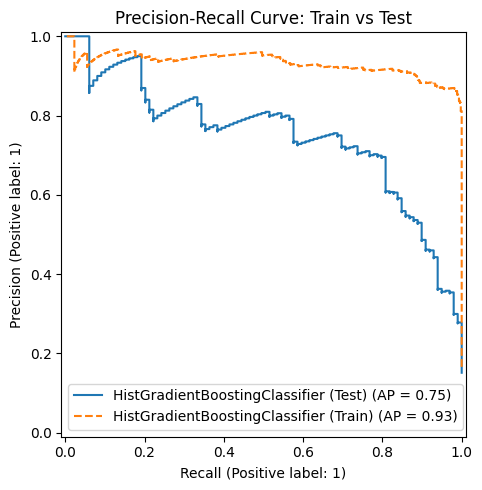

In [28]:

# PR-AUC Evaluation (Before vs After Tuning)

# Prediksi probabilitas untuk PR-AUC
y_train_pred_proba = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.decision_function(X_train)
y_test_pred_proba  = best_model.predict_proba(X_test)[:, 1]  if hasattr(best_model, 'predict_proba') else best_model.decision_function(X_test)

pr_auc_train = average_precision_score(y_train, y_train_pred_proba)
pr_auc_test  = average_precision_score(y_test,  y_test_pred_proba)

print(f"PR-AUC Train : {pr_auc_train:.4f}")
print(f"PR-AUC Test  : {pr_auc_test:.4f}")
print()

gap = abs(pr_auc_train - pr_auc_test)
print(f"PR-AUC Gap (Train vs Test): {gap:.4f}")

# Plot PR Curve
fig, ax = plt.subplots(figsize=(8, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_test_pred_proba, ax=ax, name=f'{best_model_name} (Test)')
PrecisionRecallDisplay.from_predictions(y_train, y_train_pred_proba, ax=ax, name=f'{best_model_name} (Train)', linestyle='--')
ax.set_title('Precision-Recall Curve: Train vs Test')
plt.tight_layout()
plt.show()

## 13. Model Evaluation: Can We Trust It?

### 13a. Cost-Benefit Analysis (Confusion Matrix)

Menggunakan **confusion matrix** untuk menghitung dampak bisnis dari setiap jenis prediksi:

| | Prediksi: Tidak Churn | Prediksi: Churn |
|---|---|---|
| **Aktual: Tidak Churn** | True Negative (TN) | False Positive (FP) — Biaya retensi tidak perlu |
| **Aktual: Churn** | False Negative (FN) — Kehilangan pelanggan | True Positive (TP) — Retensi berhasil |

**Asumsi Biaya:**
- **Biaya program retensi per pelanggan:** Rp 100.000 (voucher/diskon)
- **Nilai pelanggan (CLV) yang dipertahankan:** Rp 900.000
- **Kerugian kehilangan pelanggan churn (FN):** Rp 900.000


=== Confusion Matrix ===


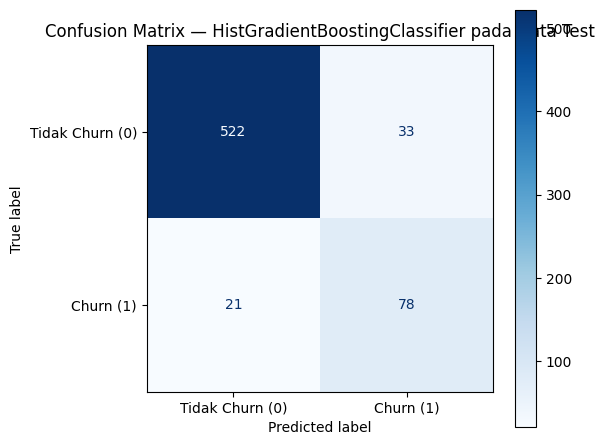


=== Classification Report ===
              precision    recall  f1-score   support

 Tidak Churn       0.96      0.94      0.95       555
       Churn       0.70      0.79      0.74        99

    accuracy                           0.92       654
   macro avg       0.83      0.86      0.85       654
weighted avg       0.92      0.92      0.92       654


=== Cost-Benefit Analysis ===
biaya tanpa model dengan skema semua pelanggan tidak ditangani
True Positive  (TP): 78 pelanggan churn berhasil dideteksi
False Positive (FP): 33 pelanggan non-churn salah diprediksi churn
False Negative (FN): 21 pelanggan churn TIDAK terdeteksi (berbahaya!)
True Negative  (TN): 522 pelanggan non-churn terdeteksi dengan benar

Benefit dari TP (CLV dipertahankan) : Rp 70,200,000
Cost dari FP (retensi tidak perlu)  : Rp 3,300,000
Cost dari FN (pelanggan hilang)     : Rp 18,900,000
Cost dari TP (biaya retensi)        : Rp 7,800,000

Net Benefit dengan Model   : Rp 40,200,000
Kerugian TANPA Model       : Rp 

In [29]:
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Churn (0)', 'Churn (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name} pada Data Test')
plt.tight_layout()
plt.show()

print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))

# Cost-Benefit Analysis
biaya_retensi     = 100_000    # Rp per pelanggan (program retensi untuk FP & TP)
nilai_clv         = 900_000  # Rp nilai pelanggan yang berhasil dipertahankan (TP)
kerugian_fn       = 900_000  # Rp kerugian per pelanggan yang tidak tertangkap (FN)

# Tanpa model (semua pelanggan tidak ditangani)
biaya_tanpa_model = fn_no_model * kerugian_fn if False else (y_test == 1).sum() * kerugian_fn

# Dengan model
benefit_tp    = tp * nilai_clv          # Pelanggan churn berhasil dipertahankan
cost_fp       = fp * biaya_retensi      # Biaya retensi untuk pelanggan yang tidak jadi churn
cost_fn       = fn * kerugian_fn        # Kehilangan pelanggan yang tidak terdeteksi
cost_tp       = tp * biaya_retensi      # Biaya retensi untuk pelanggan yang tepat

net_benefit_model   = benefit_tp - cost_fp - cost_fn - cost_tp
biaya_tanpa_model   = (y_test == 1).sum() * kerugian_fn

print("\n=== Cost-Benefit Analysis ===")
print("biaya tanpa model dengan skema semua pelanggan tidak ditangani")
print(f"True Positive  (TP): {tp} pelanggan churn berhasil dideteksi")
print(f"False Positive (FP): {fp} pelanggan non-churn salah diprediksi churn")
print(f"False Negative (FN): {fn} pelanggan churn TIDAK terdeteksi (berbahaya!)")
print(f"True Negative  (TN): {tn} pelanggan non-churn terdeteksi dengan benar")
print()
print(f"Benefit dari TP (CLV dipertahankan) : Rp {benefit_tp:,.0f}")
print(f"Cost dari FP (retensi tidak perlu)  : Rp {cost_fp:,.0f}")
print(f"Cost dari FN (pelanggan hilang)     : Rp {cost_fn:,.0f}")
print(f"Cost dari TP (biaya retensi)        : Rp {cost_tp:,.0f}")
print()
print(f"Net Benefit dengan Model   : Rp {net_benefit_model:,.0f}")
print(f"Kerugian TANPA Model       : Rp {-biaya_tanpa_model:,.0f}")
print(f"Selisih / Penghematan      : Rp {net_benefit_model + biaya_tanpa_model:,.0f}")

### 13b. Model Interpretability — SHAP

Menggunakan **SHAP (SHapley Additive exPlanations)** untuk memahami kontribusi masing-masing fitur terhadap prediksi model.


  0%|          | 0/100 [00:00<?, ?it/s]

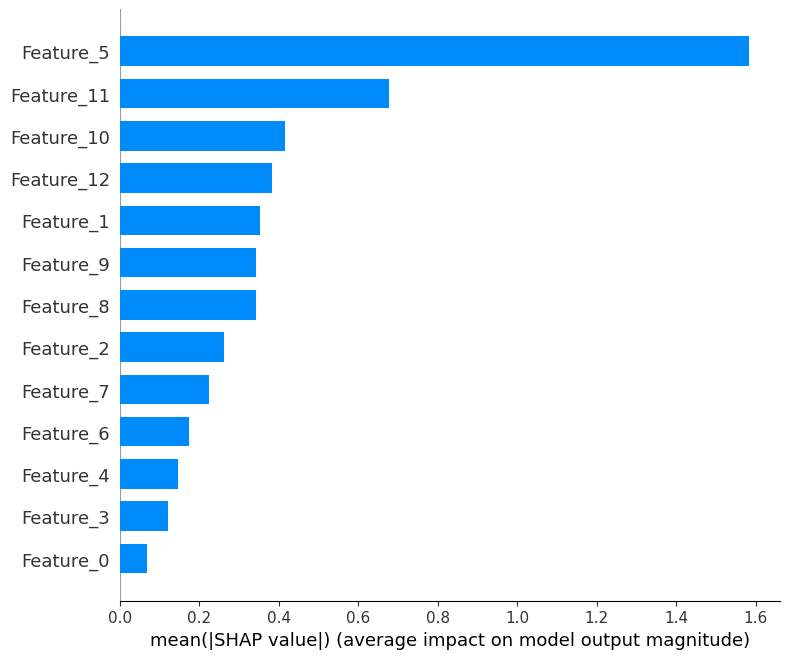

In [30]:
import shap

# Ambil sample data untuk efisiensi komputasi
X_test_transformed = best_model[:-1].transform(X_test)  # transform tanpa step classifier
X_sample = shap.sample(X_test_transformed, 100, random_state=10)

# Buat explainer
explainer = shap.KernelExplainer(best_model.named_steps['classifier'].decision_function, X_sample)
shap_values = explainer.shap_values(X_sample, nsamples=100)

# Summary Plot
shap.summary_plot(shap_values, X_sample, 
                  feature_names=[f'Feature_{i}' for i in range(X_sample.shape[1])],
                  plot_type='bar', show=True)

# Untuk mendapatkan nama fitur aktual, gunakan:
# feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
# shap.summary_plot(shap_values[1], X_sample, feature_names=feature_names)

## 14. Simpan Model (Pickle / Joblib)

Menyimpan model final terbaik menggunakan **joblib** untuk deployment.


In [31]:
import joblib
import os

# Buat direktori untuk menyimpan model jika belum ada
os.makedirs('models', exist_ok=True)

# Simpan model terbaik (pipeline lengkap)
model_path = 'models/best_churn_model.pkl'
joblib.dump(best_model, model_path)
print(f"Model '{best_model_name}' berhasil disimpan di: {model_path}")

# Verifikasi: Load kembali model dan cek prediksi
loaded_model = joblib.load(model_path)
y_pred_loaded = loaded_model.predict(X_test)

# Pastikan prediksi sama
assert (y_pred_loaded == best_model.predict(X_test)).all(), "❌ Prediksi berbeda! Ada masalah dengan serialisasi."
print(" Verifikasi berhasil: Model yang di-load menghasilkan prediksi yang sama.")
print(f"   Contoh 5 prediksi pertama: {y_pred_loaded[:5]}")

Model 'HistGradientBoostingClassifier' berhasil disimpan di: models/best_churn_model.pkl
 Verifikasi berhasil: Model yang di-load menghasilkan prediksi yang sama.
   Contoh 5 prediksi pertama: [0. 0. 0. 0. 0.]
